In [1]:
# Загрузка данных

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
ConfusionMatrixDisplay, confusion_matrix, RocCurveDisplay, classification_report)

df = load_breast_cancer()
X = pd.DataFrame(df.data, columns= df.feature_names)
display(X.head(5))
y = pd.Series(df.target, name= 'target')
display(y.tail(5))
print(y.value_counts().rename(index= {0: 'Malignant', 1: 'Bening'}))

print(f'\n\nРазмерность X:, {X.shape}')
print(f'Размерность y: {y.shape}')

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


564    0
565    0
566    0
567    0
568    1
Name: target, dtype: int64

target
Bening       357
Malignant    212
Name: count, dtype: int64


Размерность X:, (569, 30)
Размерность y: (569,)


Колличество пропусков в датасете: 0
Колличество дубликатов: 0

Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


'Новая размерность: (569, 25)'

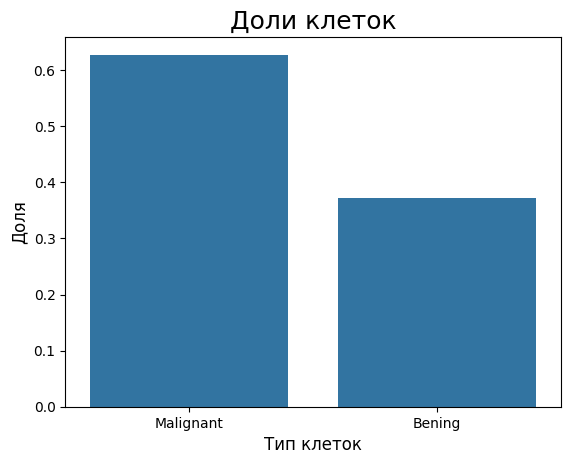

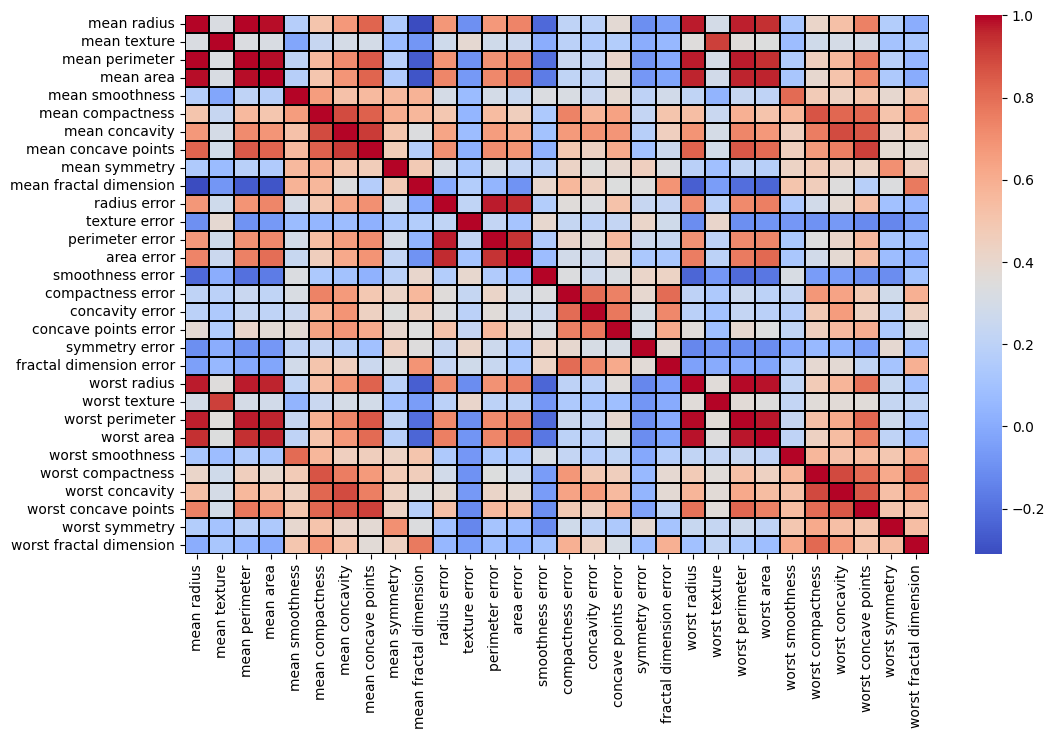

In [2]:
# Проверка данных
print(f'Колличество пропусков в датасете: {X.isna().sum().sum()}')
print(f'Колличество дубликатов: {X.duplicated().sum()}')

print("\nБазовая статистика:")
display(X.describe().T.head(10).round(2))

sns.barplot(
    x= ['Malignant', 'Bening'],
    y= y.value_counts(normalize=True)
)
plt.title('Доли клеток', fontsize= 18)
plt.xlabel('Тип клеток', fontsize = 12)
plt.ylabel('Доля', fontsize = 12)



# Матрица корреляций

plt.figure(figsize= (12, 7))
corr = X[X.columns].corr()
sns.heatmap(
    data= corr,
    annot= False,
    linewidths= 0.1,
    linecolor= 'black',
    cmap= 'coolwarm'
)
# Удаляем ненужные колонки
X = X.drop(columns= ['worst radius', 'worst perimeter', 'worst area', 'mean perimeter', 'mean area'])
display(f'Новая размерность: {X.shape}')

In [6]:
# Разделение данный и стандартизация
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42, stratify= y
)
scaler = StandardScaler().set_output(transform= 'pandas')
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print('Train shape: ', x_train_scaled.shape)
print('Test shape: ', x_test_scaled.shape)

Train shape:  (455, 25)
Test shape:  (114, 25)


In [14]:
# Реализация сигмоиды
def sigmoid(z):
    result = 1 / (1+ np.exp(-z))
    return result

print('Sigmoid(0): ', sigmoid(0))
print('Sigmoid([-1, 0, 1]): ', sigmoid(np.array([-1, 0, 1])))

Sigmoid(0):  0.5
Sigmoid([-1, 0, 1]):  [0.26894142 0.5        0.73105858]


In [15]:
# Реализация log-loss
def compute_log_loss(y_true, y_pred_proba):
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1- 1e-15)
    loss = - np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))
    return(loss)

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


In [17]:
# Один шаг градиентного спуска
def forward_backward(X, y, w, b):
    z = np.dot(X, w) + b
    p = sigmoid(z)
    loss = compute_log_loss(y, p)

    n = X.shape[0] # общее число строк (пациентов)

    # Разница между предсказанием p и реальностью y
    error = p - y 

    # Считаем СРЕДНИЙ градиент для каждого веса (Показывает, как нужно изменить коэффициент перед каждым признаком)
    dw = (1 / n) * np.dot(X.T, error) 

    # Считаем СРЕДНИЙ градиент для смещения (Показывает, нужно ли сдвинуть предсказание всей модели вверх или вниз, независимо от признаков)
    db = np.mean(error)

    return p, loss, dw, db


n_features = x_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(x_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (25,)
db: -0.12857142857142856


In [20]:
# РАБОТА С МОДЕЛЬЮ

# Создание модели
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # 1) Инициализация: создаем веса (нули) по количеству колонок в X
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        # 2) Цикл обучения (те самые итерации)
        for i in range(self.n_iters):
            # Вызываем расчет предсказаний и градиентов
            p, loss, dw, db = forward_backward(X, y, self.w, self.b)
            
            # 3) Обновляем параметры: идем ПРОТИВ градиента
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            # 4) Сохраняем историю ошибки
            self.loss_history.append(loss)
            
            # (Опционально) Печатаем лосс каждые 500 шагов, чтобы видеть прогресс
            if i % 500 == 0:
                print(f"Итерация {i}: Loss = {loss:.4f}")
                
        return self

    def predict_proba(self, X):
        # 1) Считаем z для новых данных X
        z = np.dot(X, self.w) + self.b
        
        # 2) Пропускаем через сигмоиду, чтобы получить вероятности
        proba = sigmoid(z)
        
        return proba

    def predict(self, X):
        # 1) Получаем вероятности (используем уже написанный метод)
        proba = self.predict_proba(X)
        
        # 2) Превращаем вероятности в 0 или 1
        # Если proba >= threshold (0.5), будет True (1), иначе False (0)
        preds = (proba >= self.threshold).astype(int)
        
        return preds


Итерация 0: Loss = 0.6931
Итерация 500: Loss = 0.0919


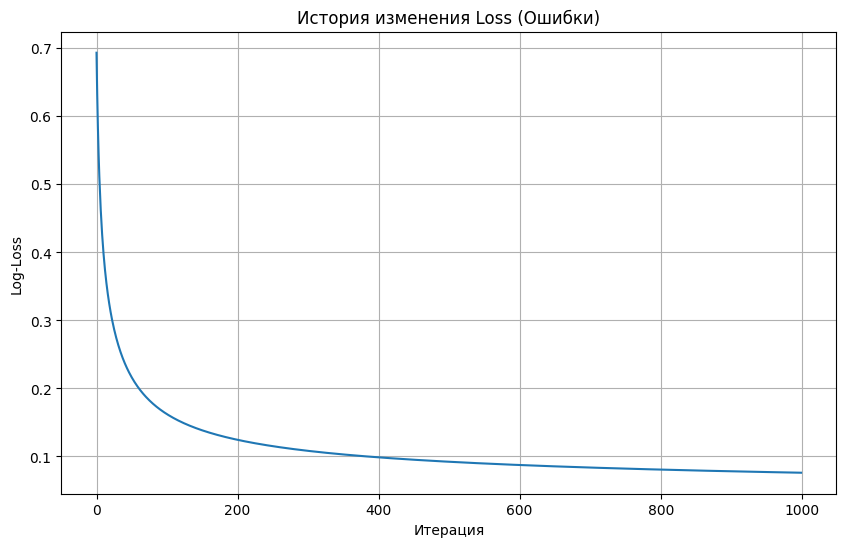

In [23]:
# Проверка созданной модели на практике
my_model = MyLogisticRegressionGD(
    learning_rate=0.05,
    n_iters=1000,    
    threshold=0.5
)

my_model.fit(x_train_scaled, y_train)


plt.figure(figsize=(10, 6))
plt.plot(my_model.loss_history)
plt.title('История изменения Loss (Ошибки)')
plt.xlabel('Итерация')
plt.ylabel('Log-Loss')
plt.grid()
plt.show()

In [62]:
# Оценка качества модели
y_pred = my_model.predict(x_test_scaled)
y_pred_probe = my_model.predict_proba(x_test_scaled)


my_metrics = {
    'acc': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recal': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_pred_probe)
}

pd.Series(my_metrics).round(4)

acc          0.9737
precision    0.9857
recal        0.9718
f1           0.9787
auc          0.9977
dtype: float64

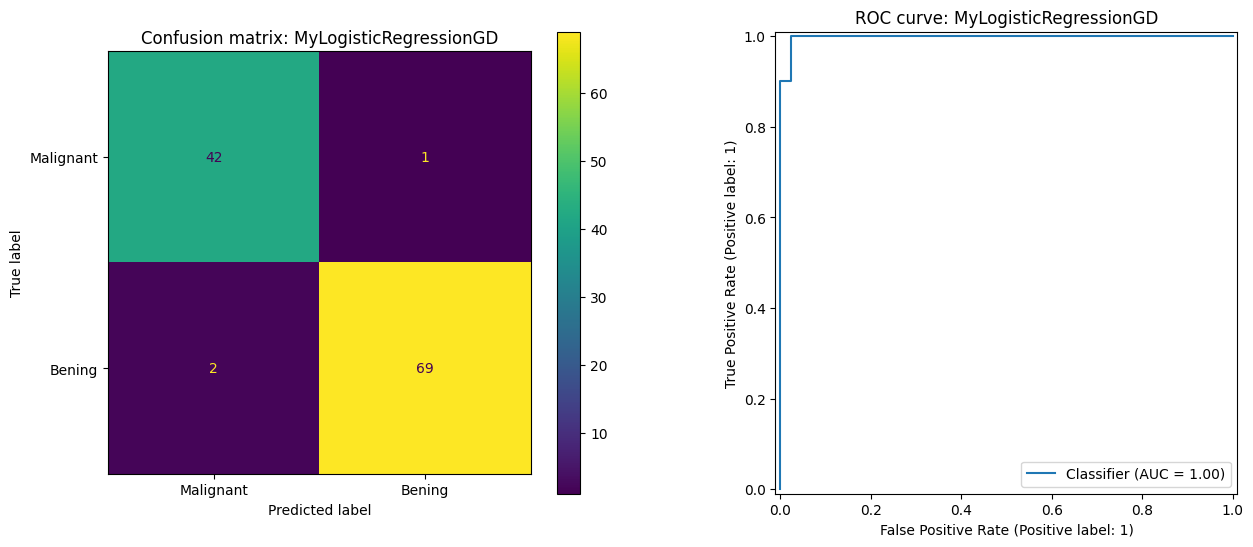

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [63]:
# Confusion matrix и ROC-кривая

fix, ax = plt.subplots(1, 2, figsize = (15, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels= ['Malignant', 'Bening'] ,ax = ax[0])
ax[0].set_title('Confusion matrix: MyLogisticRegressionGD')


RocCurveDisplay.from_predictions(y_test, y_pred_probe,ax = ax[1])
ax[1].set_title('ROC curve: MyLogisticRegressionGD')

plt.show()


print(classification_report(y_test, y_pred))

In [64]:
# Сравнение с `scikit-learn`

sk_model = LogisticRegression(max_iter=1000)

sk_model.fit(x_train_scaled, y_train)

y_pred_sk = sk_model.predict(x_test_scaled)
y_pred_probe_sk = sk_model.predict_proba(x_test_scaled)

sk_metrics = {
    'acc': accuracy_score(y_test, y_pred_sk),
    'precision': precision_score(y_test, y_pred_sk),
    'recal': recall_score(y_test, y_pred_sk),
    'f1': f1_score(y_test, y_pred_sk),
    'auc': roc_auc_score(y_test, y_pred_probe_sk[:, 1])
}

pd.Series(sk_metrics).round(4)

acc          0.9737
precision    0.9722
recal        0.9859
f1           0.9790
auc          0.9967
dtype: float64

In [65]:
# Сводная таблица сравнения
comparison = pd.DataFrame([my_metrics, sk_metrics], index= ['my_model', 'sk_model'])
display(comparison)

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values('abs_diff', ascending= False))

,acc,precision,recal,f1,auc
my_model,0.973684,0.985714,0.971831,0.978723,0.997707
sk_model,0.973684,0.972222,0.985915,0.979021,0.996725


,feature,my_coef,sklearn_coef,abs_diff
23,worst symmetry,-0.679261,-1.327554,0.648293
8,radius error,-0.849391,-1.435363,0.585972
18,worst texture,-0.815091,-1.394339,0.579248
5,mean concave points,-0.943966,-1.406130,0.462164
3,mean compactness,-0.073712,0.388141,0.461853
11,area error,-0.788497,-1.214638,0.426141
0,mean radius,-1.193139,-1.606553,0.413414
21,worst concavity,-0.613138,-0.967457,0.354319
16,symmetry error,0.308893,0.637318,0.328425
6,mean symmetry,0.051845,0.341242,0.289397


In [66]:
# Эксперимент с порогами классификации
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    pred_thr = (y_pred_probe >= threshold).astype(int) 
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9737,0.9595,1.0000,0.9793
1,0.5,0.9737,0.9857,0.9718,0.9787
2,0.7,0.9561,0.9853,0.9437,0.9640


1. Почему для логистической регрессии используется сигмоида?
Сигмоида необходима для ограничения выходных значений модели диапазоном [0,1]. Линейная регрессия может выдавать любые числа, что невозможно интерпретировать как вероятность. Сигмоида сжимает любой результат линейного уравнения в вероятность принадлежности к классу.
2. Почему в этой задаче мы считаем log-loss, а не MSE?
MSE (среднеквадратичная ошибка) в задачах классификации делает функцию потерь невыпуклой (имеет много локальных минимумов), из-за чего градиентный спуск может не найти оптимальное решение. Log-loss является выпуклой функцией и гораздо жестче штрафует за «уверенные ошибки» (когда модель уверена в классе 0, а на деле там класс 1).
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
Стандартизация приводит признаки к единому масштабу, что делает «поверхность» функции потерь более симметричной. Это позволяет градиентному спуску быстрее и стабильнее сходиться к минимуму, избегая резких скачков и колебаний.
4. Насколько близки метрики вашей реализации к scikit-learn?
Метрики моей реализации очень близки к результатам scikit-learn (presicion даже немного выше). Это подтверждает математическую корректность написанного вручную алгоритма градиентного спуска.
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
scikit-learn использует продвинутые оптимизаторы. Наша реализация — это базовый градиентный спуск, который проще, но менее эффективен на сложных данных.
6. Как изменение порога влияет на precision и recall?
Повышение порога (например, до 0.7) делает модель «осторожной»: Precision растет (меньше ложных срабатываний), но Recall падает (мы пропускаем больше реальных случаев).
Понижение порога (до 0.3) делает модель «чувствительной»: Recall растет (находим почти всех здоровых/больных), но Precision падает (появляется много ложных тревог).
7. В каких задачах логистическая регрессия хороша, а где уступает?
Хороша: В медицине и биоинформатике, где важна интерпретируемость (мы видим веса признаков/генов) и когда данные линейно разделимы. Она быстрая и не требует огромных ресурсов.
Уступает: В задачах со сложными нелинейными связями (анализ изображений, текстов), где лучше работают деревья решений, градиентный бустинг или нейронные сети.

In [70]:
#Топ-10 признаков
comparison_w = pd.DataFrame({
    'feature': X.columns,
    'my_coef': np.abs(my_model.w)
})
display(comparison_w.sort_values('my_coef', ascending = False).head(10))

,feature,my_coef
0,mean radius,1.193139
5,mean concave points,0.943966
22,worst concave points,0.866801
8,radius error,0.849391
18,worst texture,0.815091
11,area error,0.788497
23,worst symmetry,0.679261
4,mean concavity,0.658352
10,perimeter error,0.647230
21,worst concavity,0.613138


Заключение и выводы по работе

1. Сравнительный анализ реализаций
В ходе работы была разработана собственная реализация логистической регрессии с использованием метода градиентного спуска. Сравнение с библиотечной моделью scikit-learn показало идентичные результаты по метрике Accuracy (0.9737). Это подтверждает корректность математической реализации ключевых компонентов: сигмоиды, логарифмической функции потерь (Log-loss) и алгоритма обновления весов.
Небольшие численные расхождения в коэффициентах моделей (abs_diff в диапазоне 0.3–0.6) обусловлены использованием в моей реализации базового градиентного спуска, в то время как scikit-learn применяет более сложные оптимизационные алгоритмы и встроенную регуляризацию. Однако высокая сходимость метрик свидетельствует о том, что созданная модель успешно находит оптимальную разделяющую гиперплоскость.
2. Интерпретация метрик и порога классификации
Эксперимент с изменением порога классификации (от 0.3 до 0.7) выявил классическую зависимость между точностью (Precision) и полнотой (Recall):
При пороге 0.3 модель достигла максимальной чувствительности (Recall = 1.0000), безошибочно определив все случаи класса Benign в тестовой выборке. В задачах медицинской диагностики (скрининг рака груди) такой подход является предпочтительным, так как он минимизирует риск пропуска патологии (ошибки второго рода).
При пороге 0.7 модель стала более селективной, демонстрируя высокую точность (Precision = 0.9853), но при этом пропустила часть объектов целевого класса.
ROC-AUC (0.9977) подтверждает отличную способность модели разделять классы вне зависимости от выбранного порога.
3. Итоговый вывод
Логистическая регрессия показала себя как высокоэффективный и интерпретируемый инструмент для бинарной классификации медицинских данных. Она особенно эффективна в задачах, где признаки имеют линейную разделимость, а исследователю необходимо понимать вклад каждого конкретного параметра в итоговый диагноз. Разработанная «с нуля» модель полностью подтвердила свою работоспособность и аналитическую ценность на реальном наборе данных.